In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os
import geopandas as gpd
from copy import deepcopy
from textwrap import wrap
import matplotlib.ticker as mtick
import random
from shapely.geometry import Point
import fiona

In [54]:
c = fiona.open('./PCAs/US_PCA.shp')
print(c.crs)
print(gpd.read_file('./PCAs/US_PCA.shp').crs)

DriverError: Failed to open dataset (flags=68): ./PCAs/US_PCA.shp

In [ ]:
usa = gpd.read_file('./PCAs/US_PCA.shp')
df3 = pd.DataFrame(usa)
geo_df = gpd.GeoDataFrame(df3)
geo_df = geo_df.set_crs("ESRI:102008")
#geo_df = geo_df.to_crs("EPSG:4326")
geo_df = geo_df.to_crs("EPSG:4269")
#geo_df = geo_df.to_crs("EPSG:4267")
geo_df.head()

,OBJECTID_1,rb,st,rto,interconne,country,custreg,geometry
0,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473..."
1,4,p10,ca,rto4,wscc,usa,Pacific,"MULTIPOLYGON (((-118.39768 32.82017, -118.4245..."
2,5,p100,va,rto7,eastern,usa,Southeast,"POLYGON ((-77.82648 39.13924, -77.85119 39.104..."
3,6,p101,fl,rto16,eastern,usa,Southeast,"MULTIPOLYGON (((-81.66265 24.58591, -81.68301 ..."
4,7,p102,fl,rto16,eastern,usa,Southeast,"MULTIPOLYGON (((-80.16867 25.8474, -80.1335 25..."


<Axes: >

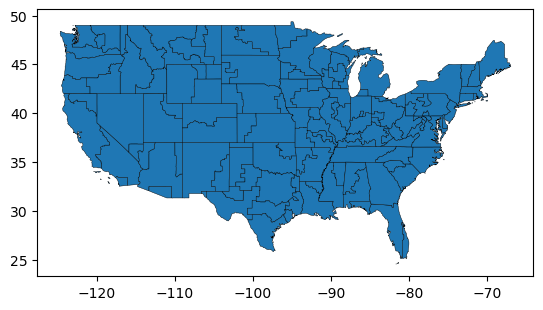

In [ ]:
geo_df.plot(edgecolor='black', linewidth=0.3)

In [ ]:
# Plots cencus block groups on a map of Oregon

def mapping_results(geo_df, column_to_map, label_color, color_input, points, extreme_ax_limit):
    fig = plt.figure()
    ax = fig.add_axes([0, 0, 1, 1])
    color_scale = color_input

    ax.axis('off')
    ax.margins(0)
    
    if extreme_ax_limit:
        vmin, vmax = 0, 100
    else:
        vmin, vmax = geo_df[column_to_map].min(), geo_df[column_to_map].max()
    
    sm = plt.cm.ScalarMappable(cmap=color_scale, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, fraction=0.025, label=label_color, ax=ax)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label(label=label_color, size=13)
    cbar.ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

    geo_df.plot(ax=ax, column=column_to_map, cmap=color_scale, vmin=vmin, vmax=vmax, edgecolor='black', linewidth=0.3)
    
    if points:
        geo_df_recycler['geometry'].plot(ax=ax, markersize=20, color='black', marker='^', label='Recycling facilities')
        plt.legend(prop={'size': 15}, labelcolor='black', frameon=False, bbox_to_anchor=(1.02, 1.12))

In [105]:
list_csv_file = []
for i in range(0, 10, 1):
    list_csv_file.append("results/run_test_all/Results_model_run_%s.csv" % i)
list_dataframe = []
seed = 0
for filename in list_csv_file:
    df = pd.read_csv(filename)
    df['seed'] = seed
    list_dataframe.append(df)
    seed += 1
data_in = pd.concat(list_dataframe)
data_in.tail()

,Unnamed: 0,Year,Quarter,Agents repairing,Agents selling,Agents recycling,Agents landfilling,Agents storing,Agents buying new,Agents buying used,Agents buying certified,Waste (kg) by pca,Waste (kg) refurbishers,Tot waste (W) by pca,Tot waste (m2) by pca,Tot install (W) by pca,Tot install (W) by pca TEST,seed
39,39,2029,4,0,0,25,16,354,395,0,0,"{'p12': {'repair': 0, 'sell': 0, 'recycle': np...","{'repair': 0, 'sell': np.float64(-18244.712721...","{'p12': np.float64(49044298.84553939), 'p13': ...","{'p12': np.float64(351860.62809517805), 'p13':...","{'p12': np.float64(939851246.6287482), 'p13': ...",7.169348e+10,9
40,40,2030,1,0,0,18,12,365,395,0,0,"{'p12': {'repair': 0, 'sell': 0, 'recycle': np...","{'repair': 0, 'sell': np.float64(-18244.712721...","{'p12': np.float64(53470104.34531187), 'p13': ...","{'p12': np.float64(383767.8266042219), 'p13': ...","{'p12': np.float64(945124434.1499983), 'p13': ...",7.405285e+10,9
41,41,2030,2,0,0,17,8,370,395,0,0,"{'p12': {'repair': 0, 'sell': 0, 'recycle': np...","{'repair': 0, 'sell': np.float64(-18244.712721...","{'p12': np.float64(59697131.20366027), 'p13': ...","{'p12': np.float64(428578.1133900527), 'p13': ...","{'p12': np.float64(950397621.6712484), 'p13': ...",7.641221e+10,9
42,42,2030,3,0,0,31,14,350,395,0,0,"{'p12': {'repair': 0, 'sell': 0, 'recycle': np...","{'repair': 0, 'sell': np.float64(-18244.712721...","{'p12': np.float64(65924158.06200867), 'p13': ...","{'p12': np.float64(473388.4001758835), 'p13': ...","{'p12': np.float64(955670809.1924986), 'p13': ...",7.877158e+10,9
43,43,2030,4,0,0,21,8,366,395,0,0,"{'p12': {'repair': 0, 'sell': 0, 'recycle': np...","{'repair': 0, 'sell': np.float64(-18244.712721...","{'p12': np.float64(72151184.92035708), 'p13': ...","{'p12': np.float64(518198.6869617143), 'p13': ...","{'p12': np.float64(960943996.7137487), 'p13': ...",8.113095e+10,9


In [106]:
def converting_dic(df, variable_name, other_columns, new_col_name, map_eval):
    columns_to_keep = other_columns + [variable_name]
    df2 = df[columns_to_keep]
    if map_eval:
        df2[variable_name] = df2[variable_name].map(eval)
    df2 = pd.concat([df2.drop([variable_name], axis=1), 
                          df2[variable_name].apply(pd.Series)], axis=1)

    column_list = df2.drop(other_columns, axis=1).columns.tolist()
    data_out = pd.DataFrame()
    for i in range(len(column_list)):
        consolidated_column_list = other_columns + [column_list[i]]
        data = df2[consolidated_column_list]
        # if column_list[i] == 'p1':
        #     print(data)
        data = data.melt(other_columns, var_name='cols', value_name='vals')
        data_out = pd.concat([data_out, data])
    data_out = data_out.rename(columns={"cols": new_col_name, "vals": 
                                  variable_name})
    return data_out

In [107]:
data_out = converting_dic(data_in, 'Waste (kg) by pca', ['Year'], 'PCAs', True)

data_out.head()

/var/folders/cq/bwvx6frs3c51r1fdv6lz4c_jkxglgm/T/ipykernel_14272/3967819232.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[variable_name] = df2[variable_name].map(eval)


,Year,PCAs,Waste (kg) by pca
0,2020,p12,"{'repair': 0, 'sell': 0, 'recycle': 0, 'landfi..."
1,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy..."
2,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy..."
3,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy..."
4,2021,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy..."


In [108]:
data_in3 = data_out.copy()
data_out2 = converting_dic(data_in3, 'Waste (kg) by pca', ['Year', 'PCAs'], 'EOL pathway', False)

data_out2.head()

,Year,PCAs,EOL pathway,Waste (kg) by pca
0,2020,p12,repair,0.0
1,2020,p12,repair,0.0
2,2020,p12,repair,0.0
3,2020,p12,repair,0.0
4,2021,p12,repair,0.0


In [109]:
data_out2["EOL pathway"].unique()

array(['repair', 'sell', 'recycle', 'landfill', 'hoard'], dtype=object)

In [110]:
data_out3 = data_out2.groupby(['Year', 'PCAs', 'EOL pathway'], as_index=False).mean(numeric_only=False)
data_out3['rb'] = data_out3['PCAs']
data_out3.head()

,Year,PCAs,EOL pathway,Waste (kg) by pca,rb
0,2020,p12,hoard,19253.879549,p12
1,2020,p12,landfill,313.075807,p12
2,2020,p12,recycle,453.197921,p12
3,2020,p12,repair,0.000000,p12
4,2020,p12,sell,313.075807,p12


In [111]:
total_amount = data_out3.groupby(['Year', 'PCAs'], as_index=False).sum()
total_amount['rb'] = total_amount['PCAs']
total_amount.head()

,Year,PCAs,EOL pathway,Waste (kg) by pca,rb
0,2020,p12,hoardlandfillrecyclerepairsell,2.033323e+04,p12
1,2020,p13,hoardlandfillrecyclerepairsell,4.454140e+05,p13
2,2020,p27,hoardlandfillrecyclerepairsell,4.241991e+03,p27
3,2020,p28,hoardlandfillrecyclerepairsell,1.533255e+06,p28
4,2020,p29,hoardlandfillrecyclerepairsell,9.534895e+01,p29


In [98]:
geo_df2 = pd.merge(geo_df, data_out3, on="rb")
geo_df3 = pd.merge(geo_df, total_amount, on="rb")

NameError: name 'geo_df' is not defined

In [ ]:
geo_df2.head()

,OBJECTID_1,rb,st,rto,interconne,country,custreg,geometry,Year,PCAs,EOL pathway,Waste (kg) by pca
0,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,hoard,0.0
1,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,landfill,0.0
2,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,recycle,0.0
3,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,repair,0.0
4,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,sell,0.0


In [ ]:
geo_df3.head()

,OBJECTID_1,rb,st,rto,interconne,country,custreg,geometry,Year,PCAs,EOL pathway,Waste (kg) by pca
0,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2020,p1,hoardlandfillrecyclerepairsell,0.000000
1,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2021,p1,hoardlandfillrecyclerepairsell,441.725975
2,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2022,p1,hoardlandfillrecyclerepairsell,931.648349
3,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2023,p1,hoardlandfillrecyclerepairsell,1852.050148
4,3,p1,wa,rto1,wscc,usa,Pacific,"MULTIPOLYGON (((-122.96072 47.14449, -122.9473...",2024,p1,hoardlandfillrecyclerepairsell,3478.372198


In [ ]:
geo_df4 = geo_df3[geo_df3['Year'] == 2035]
geo_df4['Waste (kg) by pca'] = geo_df4['Waste (kg) by pca'] / 1E6  # kg to thousand tons

ValueError: aspect must be finite and positive 

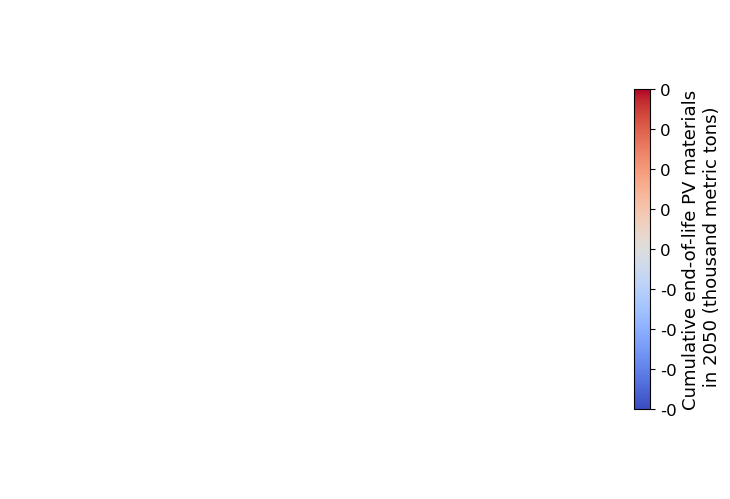

In [ ]:
mapping_results(geo_df4, 'Waste (kg) by pca', 'Cumulative end-of-life PV materials\n in 2050 (thousand metric tons)',
                'coolwarm', False, False)
plt.savefig('TotalAmount2050.png', bbox_inches='tight', pad_inches=0.1)

In [37]:
print('Total waste in 2050:', geo_df4['Waste (kg) by pca'].sum(), 'thousand tons')

NameError: name 'geo_df4' is not defined

In [112]:
waste_check = converting_dic(data_in, 'Tot waste (m2) by pca', ['Year'], 'PCAs', True)
waste_check = waste_check.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=False)
waste_check = waste_check[waste_check['Year'] == 2030]
waste_check['Tot waste (m2) by pca'] /= 1E6
waste_check['Tot waste (m2) by pca'] *= 12.6
waste_check.head()
print('Checking total waste in 2050:', waste_check['Tot waste (m2) by pca'].sum(), 'thousand tons')

Checking total waste in 2050: 665.922141417203 thousand tons


/var/folders/cq/bwvx6frs3c51r1fdv6lz4c_jkxglgm/T/ipykernel_14272/3967819232.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[variable_name] = df2[variable_name].map(eval)


In [113]:
# getting the EOL pathway rates

data_rates = pd.DataFrame(columns=data_out.columns, data=deepcopy(data_out.values))

def normalize_data_dic(x):
    tot = sum(x.values())
    if tot != 0:
        for k, v in x.items():
            x[k] = v / tot * 100
    return x

data_rates['Waste (%) by pca'] = pd.Series(data=deepcopy(data_rates['Waste (kg) by pca'].values))
data_rates['Waste (%) by pca'] = data_rates['Waste (%) by pca'].map(normalize_data_dic)

data_rates.tail()

,Year,PCAs,Waste (kg) by pca,Waste (%) by pca
8355,2029,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...","{'repair': 0.0, 'sell': 0.03436222806771844, '..."
8356,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...","{'repair': 0.0, 'sell': 0.031705444628582616, ..."
8357,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...","{'repair': 0.0, 'sell': 0.02842804707025759, '..."
8358,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...","{'repair': 0.0, 'sell': 0.025764741111347255, ..."
8359,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...","{'repair': 0.0, 'sell': 0.021584025027974654, ..."


In [114]:
def add_circular_pathway_rate(x):
    circularity_rate = 0
    for k, v in x.items():
        if k == 'repair' or k == 'sell' or k == 'recycle':
            circularity_rate += v
    return circularity_rate

data_rates['Circularity rate (%)'] = data_rates['Waste (%) by pca'].map(add_circular_pathway_rate)
data_rates['Landfill and storage rate (%)'] = 100 - data_rates['Circularity rate (%)']

data_rates.head()

,Year,PCAs,Waste (kg) by pca,Waste (%) by pca,Circularity rate (%),Landfill and storage rate (%)
0,2020,p12,"{'repair': 0, 'sell': 0, 'recycle': 0, 'landfi...","{'repair': 0, 'sell': 0, 'recycle': 0, 'landfi...",0.000000,100.000000
1,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...","{'repair': 0.0, 'sell': 9.523809523809524, 're...",9.523810,90.476190
2,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...","{'repair': 0.0, 'sell': 7.69862489650039, 'rec...",8.611217,91.388783
3,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...","{'repair': 0.0, 'sell': 6.460505321724959, 're...",7.226331,92.773669
4,2021,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...","{'repair': 0.0, 'sell': 5.565450290502098, 're...",6.225177,93.774823


In [41]:
data_rates = data_rates.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
data_rates['rb'] = data_rates['PCAs']
geo_df5 = pd.merge(geo_df, data_rates, on="rb")
geo_df5.head()

NameError: name 'geo_df' is not defined

In [52]:
recycler_lat_long = pd.read_csv('recycler_data.csv')
lat_list = recycler_lat_long['Latitude'].to_list()
long_list = recycler_lat_long['Longitude'].to_list()

geometry = [Point(xy) for xy in zip(long_list, lat_list)]

geo_df_recycler = gpd.GeoDataFrame(recycler_lat_long , geometry=geometry)

# geo_df_recycler = geo_df_recycler.set_crs("EPSG:4267")
#geo_df_recycler = geo_df_recycler.set_crs('EPSG:3857')
#geo_df_recycler = geo_df_recycler.set_crs("EPSG:4269")
geo_df_recycler = geo_df_recycler.set_crs("WGS84")

geo_df_recycler = geo_df_recycler.to_crs("EPSG:4269")
# geo_df_recycler = geo_df_recycler.to_crs("ESRI:102003")
# geo_df_recyclerf = geo_df_recycler.to_crs("ESRI:102003")

geo_df_recycler.head()

FileNotFoundError: [Errno 2] No such file or directory: 'recycler_data.csv'

In [ ]:
# geo_df5 = geo_df5.to_crs("EPSG:4326")

ValueError: aspect must be finite and positive 

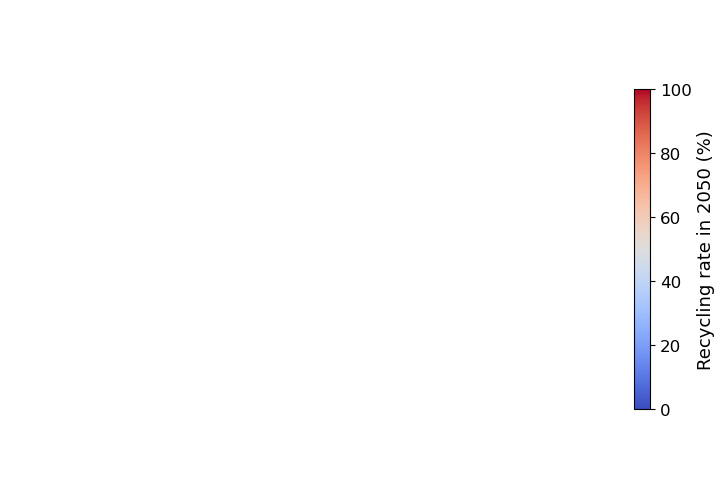

In [ ]:
geo_df6 = geo_df5[geo_df5['Year'] == 2035]
mapping_results(geo_df6, 'Circularity rate (%)', 
                'Recycling rate in 2050 (%)', 'coolwarm', True, True)
plt.savefig('CircularityRate2050.png', bbox_inches='tight', pad_inches=0.1)

In [115]:
data_circularity_mass = pd.DataFrame(columns=data_out.columns, data=deepcopy(data_out.values))

def tot_circular(x):
    circularity_mass = 0
    for k, v in x.items():
        if k == 'repair' or k == 'sell' or k == 'recycle':
            circularity_mass += v
    return circularity_mass

def tot_mass(x):
    tot = sum(x.values())
    return tot

data_circularity_mass['Total circular mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_circular)
data_circularity_mass['Total mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_mass)

data_circularity_mass.head(6)

,Year,PCAs,Waste (kg) by pca,Total circular mass by pca,Total mass by pca
0,2020,p12,"{'repair': 0, 'sell': 0, 'recycle': 0, 'landfi...",0.000000,0.000000
1,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...",2087.172049,21915.306512
2,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...",2334.584696,27110.972112
3,2020,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...",2334.584696,32306.637713
4,2021,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...",2334.584696,37502.303314
5,2021,p12,"{'repair': 0, 'sell': 2087.172048734472, 'recy...",2334.584696,47587.525018


In [116]:
data_circ_rate = data_circularity_mass[data_circularity_mass['Year'] == 2025]

data_circ_rate = data_circ_rate.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)

average_circularity_rate = (data_circ_rate['Total circular mass by pca'].sum() / 
                                 data_circ_rate['Total mass by pca'].sum() * 100)
print('National circularity rate in 2025:', average_circularity_rate, '%')

National circularity rate in 2025: 9.424273371251532 %


In [117]:
data_circ_rate = data_circularity_mass[data_circularity_mass['Year'] == 2030]
avg_pca_circ_rate = data_circ_rate.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
avg_pca_circ_rate['Recycling rate (%)'] = (avg_pca_circ_rate['Total circular mass by pca'] / 
                                           avg_pca_circ_rate['Total mass by pca'] * 100)

average_circularity_rate = (data_circ_rate['Total circular mass by pca'].sum() / 
                                 data_circ_rate['Total mass by pca'].sum() * 100)

print('National circularity rate in 2051:', average_circularity_rate, '%')
print('Average PCA circularity rate in 2051:', avg_pca_circ_rate['Recycling rate (%)'].mean(), '%')
print('Maximum PCA circularity rate in 2051:', avg_pca_circ_rate['Recycling rate (%)'].max(), '%')

National circularity rate in 2051: 9.77087927312316 %
Average PCA circularity rate in 2051: 16.409943739232133 %
Maximum PCA circularity rate in 2051: 36.646096676380296 %


In [118]:
def tot_recycle(x):
    return x['recycle']

data_circularity_mass['Total recycled mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_recycle)

data_circularity_mass.tail()

,Year,PCAs,Waste (kg) by pca,Total circular mass by pca,Total mass by pca,Total recycled mass by pca
8355,2029,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",14308.321293,402630.024525,14169.968645
8356,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,436368.733878,18387.307315
8357,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,486676.580190,18387.307315
8358,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,536984.426501,18387.307315
8359,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",84805.932808,640995.584081,84667.580161


In [119]:
data_mass_grouped = data_circularity_mass.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
data_mass_grouped['recycling_rate'] = (data_mass_grouped['Total recycled mass by pca'] / 
                                       data_mass_grouped['Total mass by pca'])

data_mass_grouped.tail()

,Year,PCAs,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,recycling_rate
204,2030,p63,1.312209e+06,7.480656e+06,1.210612e+06,0.161832
205,2030,p64,4.147291e+05,3.648773e+06,3.715422e+05,0.101827
206,2030,p65,2.408543e+06,2.255692e+07,2.138446e+06,0.094802
207,2030,p66,6.502211e+03,2.412816e+04,5.486898e+03,0.227406
208,2030,p67,5.130496e+04,5.769413e+05,3.966621e+04,0.068753


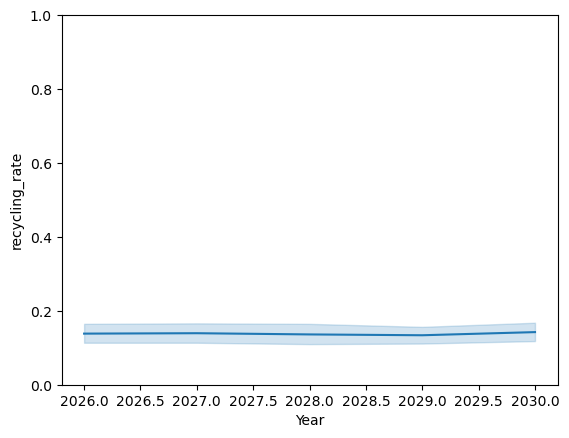

In [120]:
from statistics import mean

lineplot_df = data_mass_grouped[data_mass_grouped["Year"] > 2025]
# lineplot_df = lineplot_df.groupby(["Year", "PCAs"]).mean(numeric_only=True)

sns.lineplot(data=lineplot_df, x="Year", y="recycling_rate")
plt.ylim(0, 1)

plt.savefig('CircularityRate_2025-2050.png', bbox_inches='tight', pad_inches=0.1)
lineplot_df.to_csv('CircularityRate_2025-2050.csv')

In [121]:
def tot_repair(x):
    return x['repair']

data_circularity_mass['Total repaired mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_repair)

data_circularity_mass.tail()

,Year,PCAs,Waste (kg) by pca,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca
8355,2029,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",14308.321293,402630.024525,14169.968645,0.0
8356,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,436368.733878,18387.307315,0.0
8357,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,486676.580190,18387.307315,0.0
8358,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,536984.426501,18387.307315,0.0
8359,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",84805.932808,640995.584081,84667.580161,0.0


In [122]:
data_mass_grouped = data_circularity_mass.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
data_mass_grouped['repair_rate'] = (data_mass_grouped['Total repaired mass by pca'] / 
                                       data_mass_grouped['Total mass by pca'])

data_mass_grouped.tail()

,Year,PCAs,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca,repair_rate
204,2030,p63,1.312209e+06,7.480656e+06,1.210612e+06,35481.400015,0.004743
205,2030,p64,4.147291e+05,3.648773e+06,3.715422e+05,17834.303557,0.004888
206,2030,p65,2.408543e+06,2.255692e+07,2.138446e+06,62779.521618,0.002783
207,2030,p66,6.502211e+03,2.412816e+04,5.486898e+03,638.376833,0.026458
208,2030,p67,5.130496e+04,5.769413e+05,3.966621e+04,712.892060,0.001236


(0.0, 1.0)

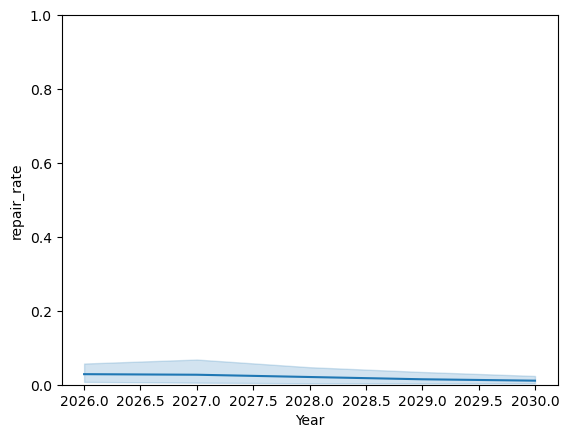

In [123]:
lineplot_df = data_mass_grouped[data_mass_grouped["Year"] > 2025]

sns.lineplot(data=lineplot_df, x="Year", y="repair_rate")
plt.ylim(0, 1)

In [124]:
def tot_reuse(x):
    return x['sell']

data_circularity_mass['Total reused mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_reuse)

data_circularity_mass.tail()

,Year,PCAs,Waste (kg) by pca,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca,Total reused mass by pca
8355,2029,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",14308.321293,402630.024525,14169.968645,0.0,138.352647
8356,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,436368.733878,18387.307315,0.0,138.352647
8357,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,486676.580190,18387.307315,0.0,138.352647
8358,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,536984.426501,18387.307315,0.0,138.352647
8359,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",84805.932808,640995.584081,84667.580161,0.0,138.352647


In [125]:
data_mass_grouped = data_circularity_mass.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
data_mass_grouped['reuse_rate'] = (data_mass_grouped['Total reused mass by pca'] / 
                                       data_mass_grouped['Total mass by pca'])

data_mass_grouped.tail()

,Year,PCAs,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca,Total reused mass by pca,reuse_rate
204,2030,p63,1.312209e+06,7.480656e+06,1.210612e+06,35481.400015,66115.315254,0.008838
205,2030,p64,4.147291e+05,3.648773e+06,3.715422e+05,17834.303557,25352.597765,0.006948
206,2030,p65,2.408543e+06,2.255692e+07,2.138446e+06,62779.521618,207317.133328,0.009191
207,2030,p66,6.502211e+03,2.412816e+04,5.486898e+03,638.376833,376.936678,0.015622
208,2030,p67,5.130496e+04,5.769413e+05,3.966621e+04,712.892060,10925.857140,0.018938


(0.0, 1.0)

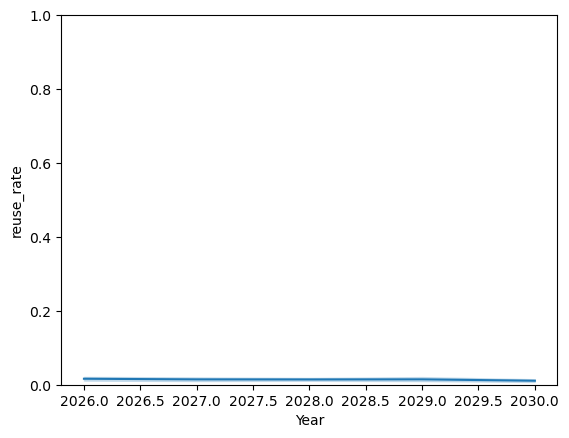

In [126]:
lineplot_df = data_mass_grouped[data_mass_grouped["Year"] > 2025]

sns.lineplot(data=lineplot_df, x="Year", y="reuse_rate")
plt.ylim(0, 1)

In [127]:
def tot_storage(x):
    return x['hoard']

data_circularity_mass['Total stored mass by pca'] = data_circularity_mass['Waste (kg) by pca'].map(tot_storage)

data_circularity_mass.tail()

,Year,PCAs,Waste (kg) by pca,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca,Total reused mass by pca,Total stored mass by pca
8355,2029,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",14308.321293,402630.024525,14169.968645,0.0,138.352647,304777.990357
8356,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,436368.733878,18387.307315,0.0,138.352647,334299.361042
8357,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,486676.580190,18387.307315,0.0,138.352647,384607.207353
8358,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",18525.659962,536984.426501,18387.307315,0.0,138.352647,434915.053665
8359,2030,p67,"{'repair': 0, 'sell': 138.3526472962243, 'recy...",84805.932808,640995.584081,84667.580161,0.0,138.352647,472645.938398


In [128]:
data_mass_grouped = data_circularity_mass.groupby(['Year', 'PCAs'], as_index=False).mean(numeric_only=True)
data_mass_grouped['storage_rate'] = (data_mass_grouped['Total stored mass by pca'] / 
                                       data_mass_grouped['Total mass by pca'])

data_mass_grouped.tail()

,Year,PCAs,Total circular mass by pca,Total mass by pca,Total recycled mass by pca,Total repaired mass by pca,Total reused mass by pca,Total stored mass by pca,storage_rate
204,2030,p63,1.312209e+06,7.480656e+06,1.210612e+06,35481.400015,66115.315254,5.275257e+06,0.705186
205,2030,p64,4.147291e+05,3.648773e+06,3.715422e+05,17834.303557,25352.597765,2.487635e+06,0.681773
206,2030,p65,2.408543e+06,2.255692e+07,2.138446e+06,62779.521618,207317.133328,1.515083e+07,0.671671
207,2030,p66,6.502211e+03,2.412816e+04,5.486898e+03,638.376833,376.936678,1.588373e+04,0.658307
208,2030,p67,5.130496e+04,5.769413e+05,3.966621e+04,712.892060,10925.857140,4.042901e+05,0.700747


(0.0, 1.0)

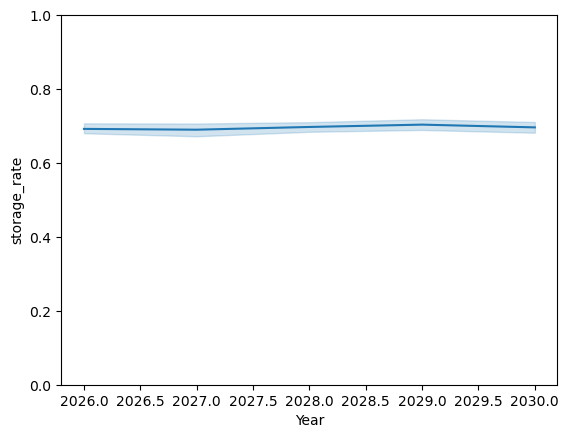

In [129]:
lineplot_df = data_mass_grouped[data_mass_grouped["Year"] > 2025]

sns.lineplot(data=lineplot_df, x="Year", y="storage_rate")
plt.ylim(0, 1)

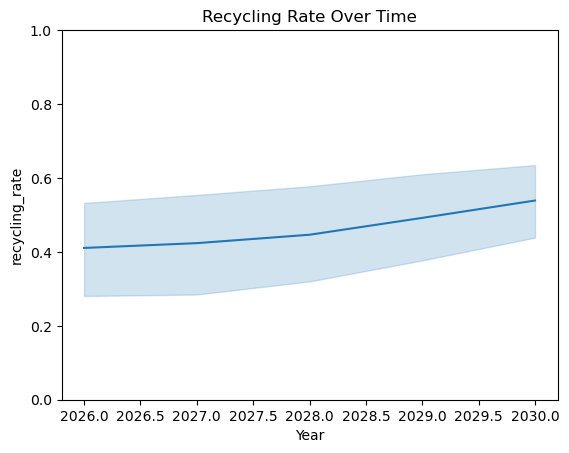

In [127]:
# Calculate and plot recycling rate
data_mass_grouped['recycling_rate'] = (data_mass_grouped['Total recycled mass by pca'] / 
                                       data_mass_grouped['Total mass by pca'])

lineplot_df = data_mass_grouped[data_mass_grouped["Year"] > 2025]
sns.lineplot(data=lineplot_df, x="Year", y="recycling_rate")
plt.ylim(0, 1)
plt.title("Recycling Rate Over Time")
plt.show()

In [ ]:
data_mass_grouped_out = data_mass_grouped.filter([
    'Year', 'PCAs', 'Total mass by pca', 'Total recycled mass by pca', 'recycling_rate'])
data_mass_grouped_out = data_mass_grouped_out[data_mass_grouped_out['Year'] > 2025]

data_mass_grouped_out['recycling_rate'] *= 100
data_mass_grouped_out.rename(columns={'PCAs': 'PCA', 'Total mass by pca': 'Total mass by pca (kg)',
                             'Total recycled mass by pca': 'Total recycled mass by pca (kg)', 
                              'recycling_rate': 'Recycling rate (%)'}, inplace=True)

pca_state_df = pd.read_csv('pca_state_dic.csv')
data_mass_grouped_out = data_mass_grouped_out.merge(pca_state_df, how='inner', on='PCA')

# data_mass_grouped_out = data_mass_grouped_out[(data_mass_grouped_out['State'] == 'AR') | (data_mass_grouped_out['State'] == 'TX')]

data_mass_grouped_out.to_csv('060225_ABM_Results.csv')

data_mass_grouped_out.head()

FileNotFoundError: [Errno 2] No such file or directory: 'pca_state_dic.csv'

In [72]:
recycling_rate_2050 = data_mass_grouped[data_mass_grouped['Year'] == 2025]

average_recycling_rate = (recycling_rate_2050['Total recycled mass by pca'].sum() / 
                                 recycling_rate_2050['Total mass by pca'].sum() * 100)

print('National recycling rate in 2025:', average_recycling_rate, '%')

National recycling rate in 2025: 1.2927224025115975 %


In [73]:
recycling_rate_2050 = data_mass_grouped[data_mass_grouped['Year'] == 2035]

average_recycling_rate = (recycling_rate_2050['Total recycled mass by pca'].sum() / 
                                 recycling_rate_2050['Total mass by pca'].sum() * 100)

print('National recycling rate in 2051:', average_recycling_rate, '%')

National recycling rate in 2051: 2.1934374467424496 %


In [74]:
def get_materials():
    df_materials = pd.read_csv('mat_factor.csv')

    df_materials['al_%'] = df_materials['aluminium_frames.csv'] / df_materials['total_massperm2']
    df_materials['backsheet_%'] = df_materials['backsheet.csv'] / df_materials['total_massperm2']
    df_materials['cu_%'] = df_materials['copper.csv'] / df_materials['total_massperm2']
    df_materials['encapsulant_%'] = df_materials['encapsulant.csv'] / df_materials['total_massperm2']
    df_materials['glass_%'] = df_materials['glass.csv'] / df_materials['total_massperm2']
    df_materials['Si_%'] = df_materials['silicon.csv'] / df_materials['total_massperm2']
    df_materials['Ag_%'] = df_materials['silver.csv'] / df_materials['total_massperm2']
    
    return df_materials

df_materials = get_materials()
df_materials.head()

FileNotFoundError: [Errno 2] No such file or directory: 'mat_factor.csv'

In [75]:
data_mass_grouped['year'] = data_mass_grouped['Year'] - 1
data_mass_grouped = data_mass_grouped.drop(['Year'], axis=1)
data_mass_grouped = data_mass_grouped[data_mass_grouped['year'] >= 2020]

df_materials = df_materials[df_materials['year'] >= 2020]
df_materials_rate_mass = pd.merge(df_materials, data_mass_grouped, on="year")

df_materials_rate_mass.head()

NameError: name 'df_materials' is not defined

In [76]:
# We don't know what was the composition of the PV panels when they became waste. We should just use the average composition

df_materials_2 = get_materials()
al_rate = df_materials_2['al_%'].mean()
backsheet_rate = df_materials_2['backsheet_%'].mean()
cu_rate = df_materials_2['cu_%'].mean()
encapsulant_rate = df_materials_2['encapsulant_%'].mean()
glass_rate = df_materials_2['glass_%'].mean()
Si_rate = df_materials_2['Si_%'].mean()
Ag_rate = df_materials_2['Ag_%'].mean()

FileNotFoundError: [Errno 2] No such file or directory: 'mat_factor.csv'

In [ ]:
df_materials_rate_mass['al_kg_recycled'] = al_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['backsheet_kg_recycled'] = backsheet_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['cu_kg_recycled'] = cu_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['encapsulant_kg_recycled'] = encapsulant_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['glass_kg_recycled'] = glass_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['Si_kg_recycled'] = Si_rate * df_materials_rate_mass['Total recycled mass by pca']
df_materials_rate_mass['Ag_kg_recycled'] = Ag_rate * df_materials_rate_mass['Total recycled mass by pca']

df_materials_rate_mass['al_kg_tot'] = al_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['backsheet_kg_tot'] = backsheet_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['cu_kg_tot'] = cu_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['encapsulant_kg_tot'] = encapsulant_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['glass_kg_tot'] = glass_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['Si_kg_tot'] = Si_rate * df_materials_rate_mass['Total mass by pca']
df_materials_rate_mass['Ag_kg_tot'] = Ag_rate * df_materials_rate_mass['Total mass by pca']

df_materials_rate_mass.head()

,year,aluminium_frames.csv,backsheet.csv,copper.csv,encapsulant.csv,glass.csv,silicon.csv,silver.csv,total_massperm2,al_%,...,glass_kg_recycled,Si_kg_recycled,Ag_kg_recycled,al_kg_tot,backsheet_kg_tot,cu_kg_tot,encapsulant_kg_tot,glass_kg_tot,Si_kg_tot,Ag_kg_tot
0,2020,1.343647,0.432533,0.008225,0.849445,8.9755,0.395542,0.003595,12.008487,0.111891,...,104.192595,5.069885,0.180356,56.893965,11.423601,0.235157,27.564298,329.029247,16.010162,0.569544
1,2020,1.343647,0.432533,0.008225,0.849445,8.9755,0.395542,0.003595,12.008487,0.111891,...,16540.318244,804.831710,28.631028,12257.411718,2461.135929,50.663031,5938.537562,70887.078190,3449.278756,122.704407
2,2020,1.343647,0.432533,0.008225,0.849445,8.9755,0.395542,0.003595,12.008487,0.111891,...,0.128336,0.006245,0.000222,0.085901,0.017248,0.000355,0.041618,0.496785,0.024173,0.000860
3,2020,1.343647,0.432533,0.008225,0.849445,8.9755,0.395542,0.003595,12.008487,0.111891,...,722.282969,35.145408,1.250260,651.617115,130.836618,2.693301,315.699008,3768.432884,183.367347,6.523098
4,2020,1.343647,0.432533,0.008225,0.849445,8.9755,0.395542,0.003595,12.008487,0.111891,...,475.716892,23.147804,0.823458,318.419622,63.934703,1.316110,154.269672,1841.484743,89.604401,3.187581


In [ ]:
list_materials = ['al_kg_', 'backsheet_kg_', 'cu_kg_', 'encapsulant_kg_', 'glass_kg_', 'Si_kg_', 'Ag_kg_']
df_mat_rt_mass_year = df_materials_rate_mass[df_materials_rate_mass['year'] == 2050]

for material in list_materials:
    print('The total for', material, 'is', df_mat_rt_mass_year[material + 'tot'].sum() / 1E6, 'thousand tons')
    print('The recycled amount for', material, 'is', df_mat_rt_mass_year[material + 'recycled'].sum() / 1E6, 'thousand tons')
    print(' ')

The total for al_kg_ is 0.0 thousand tons
The recycled amount for al_kg_ is 0.0 thousand tons
 
The total for backsheet_kg_ is 0.0 thousand tons
The recycled amount for backsheet_kg_ is 0.0 thousand tons
 
The total for cu_kg_ is 0.0 thousand tons
The recycled amount for cu_kg_ is 0.0 thousand tons
 
The total for encapsulant_kg_ is 0.0 thousand tons
The recycled amount for encapsulant_kg_ is 0.0 thousand tons
 
The total for glass_kg_ is 0.0 thousand tons
The recycled amount for glass_kg_ is 0.0 thousand tons
 
The total for Si_kg_ is 0.0 thousand tons
The recycled amount for Si_kg_ is 0.0 thousand tons
 
The total for Ag_kg_ is 0.0 thousand tons
The recycled amount for Ag_kg_ is 0.0 thousand tons
 


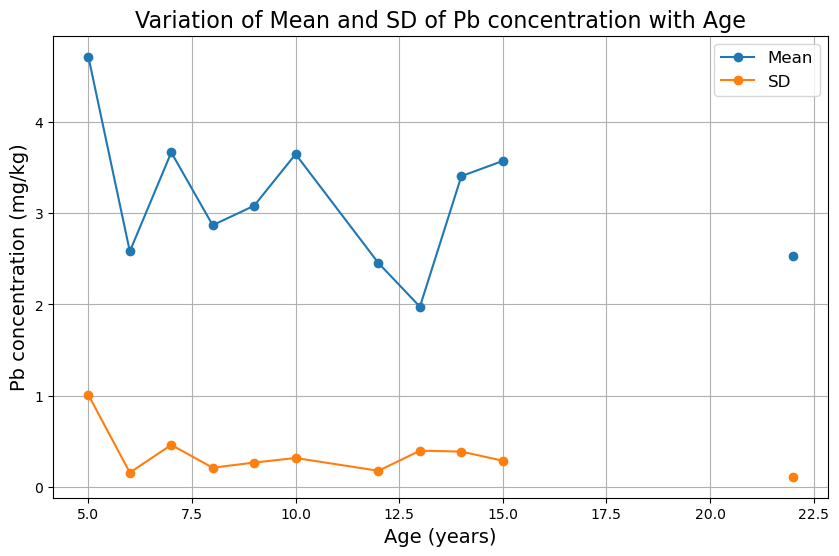

In [9]:
age_df = pd.read_csv("/Users/pghosh/SOLAR/age_vs_pb_conc.csv")
# generate a plot of how Mean and SD varies with Age
age_df.head()
grouped_df = age_df.groupby('Age').mean(numeric_only=True)
plt.figure(figsize=(10,6))
plt.plot(grouped_df.index, grouped_df['Mean'], marker='o')
plt.plot(grouped_df.index, grouped_df['SD'], marker='o')
plt.xlabel('Age (years)', fontsize=14)
plt.ylabel('Pb concentration (mg/kg)', fontsize=14)
plt.title('Variation of Mean and SD of Pb concentration with Age', fontsize=16)
plt.legend(['Mean', 'SD'], fontsize=12)
plt.grid()
plt.show()